In [45]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *

import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
from scipy.stats import wilcoxon

In [2]:
lr_model = joblib.load("../models/lr_model.pkl")
gam_model = joblib.load("../models/gam_model.pkl")
ebm_model = joblib.load("../models/ebm_model.pkl")
blr_model = joblib.load("../models/blr_model.pkl")

print("All models loaded successfully.")

All models loaded successfully.


In [40]:

lr_path = "../results/lr_comparison_metrics.csv"
gam_path = "../results/gam_evaluation_results.csv"

lr_performance_df = pd.read_csv(lr_path)
gam_performance_df = pd.read_csv(gam_path)



In [4]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [5]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

print(type(lr_model))
print(type(gam_model))
print("EBM:", type(ebm_model))
print("BLR:", type(blr_model))

if isinstance(blr_model, dict):
    print("\nBLR saved keys:")
    print(blr_model.keys())

(759384, 23)
(118799, 23)
(759384,)
(118799,)
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'pygam.pygam.LogisticGAM'>
EBM: <class 'interpret.glassbox._ebm._ebm.ExplainableBoostingClassifier'>
BLR: <class 'dict'>

BLR saved keys:
dict_keys(['alpha_mean', 'beta_mean', 'alpha_samples', 'beta_samples', 'best_prior_sd', 'columns'])


In [ ]:

n_per_class = 50

test_data = X_test.copy()
test_data["actual_label"] = y_test.values

default_cases = test_data[
    test_data["actual_label"] == 0
].sample(
    n=n_per_class,
    random_state=42
)

paid_cases = test_data[
    test_data["actual_label"] == 1
].sample(
    n=n_per_class,
    random_state=42
)

analysis_data = pd.concat(
    [default_cases, paid_cases],
    axis=0
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

y_analysis = analysis_data.pop("actual_label")
X_analysis = analysis_data

print("X_analysis shape:", X_analysis.shape)
print("\nClass distribution:")
print(y_analysis.value_counts())

X_analysis shape: (100, 23)

Class distribution:
actual_label
1.0    50
0.0    50
Name: count, dtype: int64


In [ ]:

X_lr_shap_background = X_train.sample(
    n=300,
    random_state=42
).reset_index(drop=True)


X_lime_background = X_train.sample(
    n=3000,
    random_state=42
).reset_index(drop=True)


X_gam_background_sample = X_train.sample(
    n=5000,
    random_state=42
)

gam_background = shap.kmeans(
    X_gam_background_sample,
    50
)

X_ebm_background_sample = X_train.sample(
    n=5000,
    random_state=42
)

ebm_background = shap.kmeans(
    X_ebm_background_sample,
    50
)

X_blr_background_sample = X_train.sample(
    n=5000,
    random_state=42
)

blr_background = shap.kmeans(
    X_blr_background_sample,
    50
)

print("LR SHAP background:", X_lr_shap_background.shape)
print("LIME background:", X_lime_background.shape)
print("GAM background centres:", gam_background.data.shape)
print("EBM background centres:", ebm_background.data.shape)
print("BLR background centres:", blr_background.data.shape)

LR SHAP background: (300, 23)
LIME background: (3000, 23)
GAM background centres: (50, 23)
EBM background centres: (50, 23)
BLR background centres: (50, 23)


In [ ]:

def ensure_valid_probability(probability):
    """
    Convert predictions into a clean one-dimensional probability array.
    """

    probability = np.asarray(
        probability,
        dtype=float
    ).reshape(-1)

    probability = np.nan_to_num(
        probability,
        nan=0.5,
        posinf=1.0,
        neginf=0.0
    )

    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    return probability

def gam_paid_probability(X):
    """
    Return GAM probability for class 1: Paid Back.
    """

    X_array = np.asarray(X, dtype=float)

    probability = gam_model.predict_proba(
        X_array
    )

    return ensure_valid_probability(probability)


def gam_predict_proba(X):
    """
    Return two columns required by LIME:
    column 0 = Default
    column 1 = Paid Back
    """

    prob_paid = gam_paid_probability(X)

    return np.column_stack([
        1.0 - prob_paid,
        prob_paid
    ])

def ebm_paid_probability(X):
    """
    Return EBM probability for class 1: Paid Back.
    """

    X_array = np.asarray(X, dtype=float)

    probabilities = ebm_model.predict_proba(
        X_array
    )

    prob_paid = probabilities[:, 1]

    return ensure_valid_probability(prob_paid)


def ebm_predict_proba(X):
    """
    Return EBM probabilities in two-column format for LIME.
    """

    prob_paid = ebm_paid_probability(X)

    return np.column_stack([
        1.0 - prob_paid,
        prob_paid
    ])

def blr_paid_probability(X):
    """
    Calculate class-1 probability from the saved BLR posterior means.
    """

    if not isinstance(blr_model, dict):
        raise TypeError(
            "blr_model is expected to be a dictionary containing "
            "alpha_mean and beta_mean."
        )

    required_keys = {
        "alpha_mean",
        "beta_mean"
    }

    missing_keys = required_keys.difference(
        blr_model.keys()
    )

    if missing_keys:
        raise KeyError(
            f"BLR model is missing keys: {missing_keys}"
        )

    X_array = np.asarray(
        X,
        dtype=float
    )

    alpha_mean = float(
        np.asarray(
            blr_model["alpha_mean"]
        ).squeeze()
    )

    beta_mean = np.asarray(
        blr_model["beta_mean"],
        dtype=float
    ).reshape(-1)

    if X_array.shape[1] != len(beta_mean):
        raise ValueError(
            f"BLR expects {len(beta_mean)} features, "
            f"but received {X_array.shape[1]} features."
        )

    linear_predictor = (
        alpha_mean
        + X_array @ beta_mean
    )

    linear_predictor = np.clip(
        linear_predictor,
        -500,
        500
    )

    prob_paid = 1.0 / (
        1.0 + np.exp(-linear_predictor)
    )

    return ensure_valid_probability(prob_paid)


def blr_predict_proba(X):
    """
    Return BLR probabilities in two-column format for LIME.
    """

    prob_paid = blr_paid_probability(X)

    return np.column_stack([
        1.0 - prob_paid,
        prob_paid
    ])

In [ ]:

lr_probabilities = lr_model.predict_proba(
    X_analysis
)[:, 1]

gam_probabilities = gam_paid_probability(
    X_analysis
)

ebm_probabilities = ebm_paid_probability(
    X_analysis
)

blr_probabilities = blr_paid_probability(
    X_analysis
)

prediction_summary = pd.DataFrame({
    "Borrower": np.arange(len(X_analysis)),
    "Actual_Label": y_analysis.values,
    "LR_Paid_Probability": lr_probabilities,
    "GAM_Paid_Probability": gam_probabilities,
    "EBM_Paid_Probability": ebm_probabilities,
    "BLR_Paid_Probability": blr_probabilities
})

display(
    prediction_summary.head(10)
)

,Borrower,Actual_Label,LR_Paid_Probability,GAM_Paid_Probability,EBM_Paid_Probability,BLR_Paid_Probability
0,0,1.0,0.845408,0.822274,0.945435,0.845868
1,1,1.0,0.864219,0.907441,0.959308,0.870528
2,2,1.0,0.581125,0.558691,0.724404,0.599805
3,3,0.0,0.011623,0.009303,0.015501,0.012807
4,4,0.0,0.008201,0.013237,0.009667,0.009005
5,5,0.0,0.103409,0.068376,0.044633,0.047519
6,6,0.0,0.007136,0.004581,0.005096,0.007508
7,7,1.0,0.957446,0.983048,0.989466,0.958457
8,8,0.0,0.515692,0.500072,0.757527,0.526252
9,9,0.0,0.584119,0.579287,0.923826,0.597886


In [ ]:

lr_explainer = shap.LinearExplainer(
    lr_model,
    X_lr_shap_background
)

lr_shap_values = lr_explainer(X_analysis)

print("LR SHAP values shape:", lr_shap_values.values.shape)

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


LR SHAP values shape: (100, 23)


In [ ]:

gam_explainer = shap.KernelExplainer(
    gam_paid_probability,
    gam_background
)

gam_shap_values = gam_explainer.shap_values(
    X_analysis.values,
    nsamples=200
)

gam_shap_values = np.asarray(
    gam_shap_values
)

print(
    "GAM SHAP values shape:",
    gam_shap_values.shape
)

  0%|          | 0/100 [00:00<?, ?it/s]

GAM SHAP values shape: (100, 23)


In [ ]:

ebm_explainer = shap.KernelExplainer(
    ebm_paid_probability,
    ebm_background
)

ebm_shap_values = ebm_explainer.shap_values(
    X_analysis.values,
    nsamples=200
)

ebm_shap_values = np.asarray(
    ebm_shap_values
)

print(
    "EBM SHAP values shape:",
    ebm_shap_values.shape
)

  0%|          | 0/100 [00:00<?, ?it/s]

EBM SHAP values shape: (100, 23)


In [ ]:

blr_explainer = shap.KernelExplainer(
    blr_paid_probability,
    blr_background
)

blr_shap_values = blr_explainer.shap_values(
    X_analysis.values,
    nsamples=200
)

blr_shap_values = np.asarray(
    blr_shap_values
)

print(
    "BLR SHAP values shape:",
    blr_shap_values.shape
)

  0%|          | 0/100 [00:00<?, ?it/s]

BLR SHAP values shape: (100, 23)


Borrower index: 0
Actual label: 1.0
LR paid-back probability: 0.8454


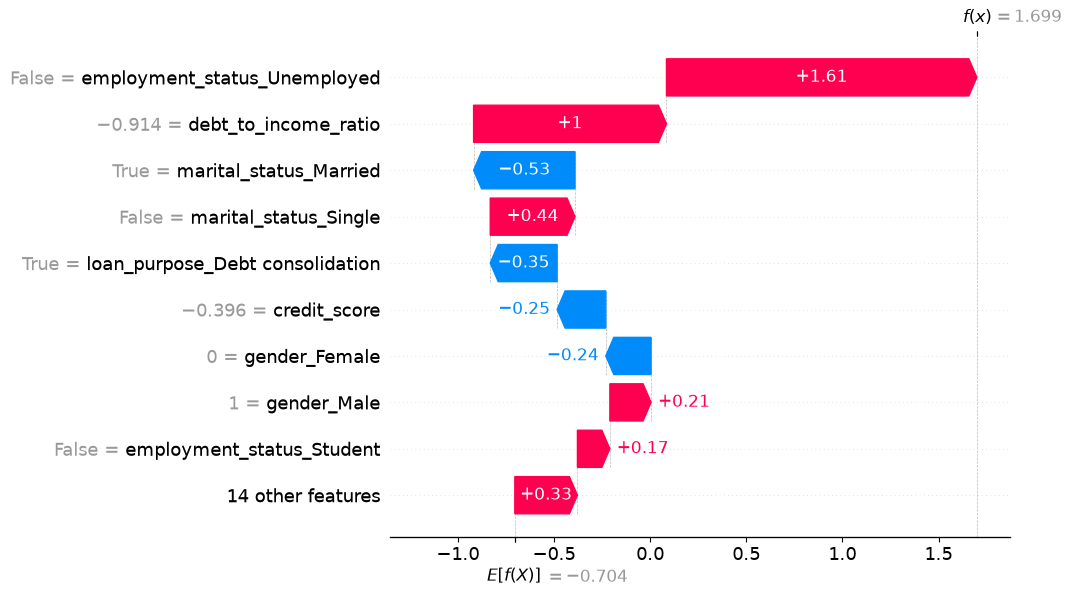

In [ ]:

borrower_index = 0

lr_paid_probability = lr_model.predict_proba(
    X_analysis.iloc[[borrower_index]]
)[0, 1]

print("Borrower index:", borrower_index)
print("Actual label:", y_analysis.iloc[borrower_index])
print(f"LR paid-back probability: {lr_paid_probability:.4f}")

shap.plots.waterfall(
    lr_shap_values[borrower_index],
    max_display=10
)

Borrower index: 0
Actual label: 1.0
GAM paid-back probability: 0.8223


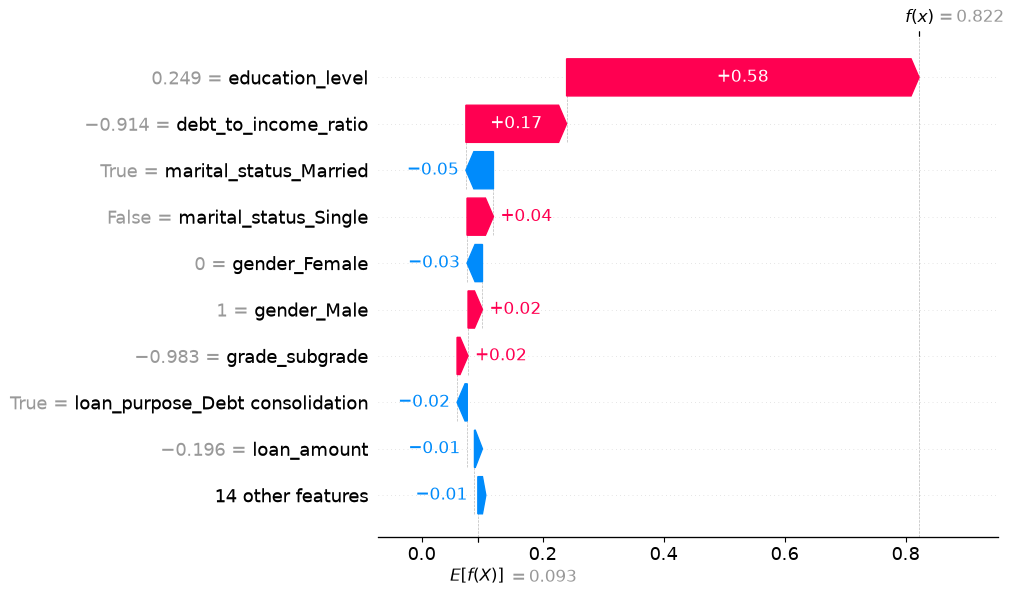

In [ ]:

gam_paid_prob = gam_paid_probability(
    X_analysis.iloc[[borrower_index]]
)[0]

print("Borrower index:", borrower_index)
print("Actual label:", y_analysis.iloc[borrower_index])
print(f"GAM paid-back probability: {gam_paid_prob:.4f}")

gam_local_explanation = shap.Explanation(
    values=gam_shap_values[borrower_index],
    base_values=gam_explainer.expected_value,
    data=X_analysis.iloc[borrower_index].values,
    feature_names=X_analysis.columns.tolist()
)

shap.plots.waterfall(
    gam_local_explanation,
    max_display=10
)

Borrower index: 0
Actual label: 1.0
EBM paid-back probability: 0.9454
Local SHAP shape: (23,)
Borrower data shape: (23,)
Number of features: 23


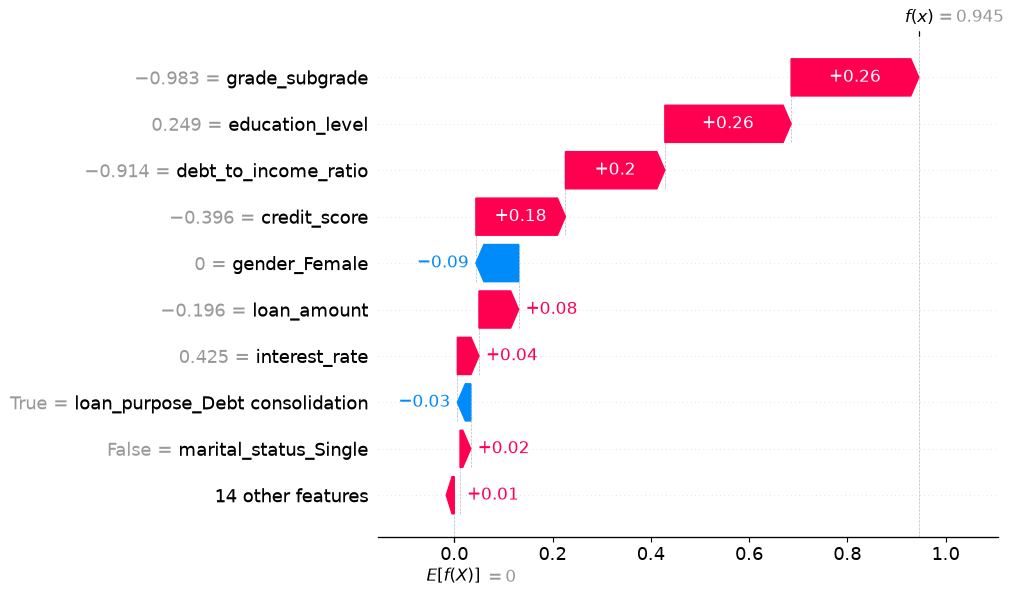

In [ ]:

ebm_paid_prob = ebm_paid_probability(
    X_analysis.iloc[[borrower_index]]
)[0]

print("Borrower index:", borrower_index)
print(
    "Actual label:",
    y_analysis.iloc[borrower_index]
)
print(
    f"EBM paid-back probability: {ebm_paid_prob:.4f}"
)

ebm_expected_value = float(
    np.asarray(
        ebm_explainer.expected_value
    ).reshape(-1)[0]
)

ebm_local_values = np.asarray(
    ebm_shap_values[borrower_index]
).reshape(-1)

ebm_local_data = X_analysis.iloc[
    borrower_index
].to_numpy().reshape(-1)

print(
    "Local SHAP shape:",
    ebm_local_values.shape
)
print(
    "Borrower data shape:",
    ebm_local_data.shape
)
print(
    "Number of features:",
    len(X_analysis.columns)
)

ebm_local_explanation = shap.Explanation(
    values=ebm_local_values,
    base_values=ebm_expected_value,
    data=ebm_local_data,
    feature_names=X_analysis.columns.tolist()
)

shap.plots.waterfall(
    ebm_local_explanation,
    max_display=10
)

Borrower index: 0
Actual label: 1.0
BLR paid-back probability: 0.8459
BLR expected value: 0.6834190724199124 <class 'float'>
BLR SHAP shape: (23,)
BLR data shape: (23,)
Number of feature names: 23


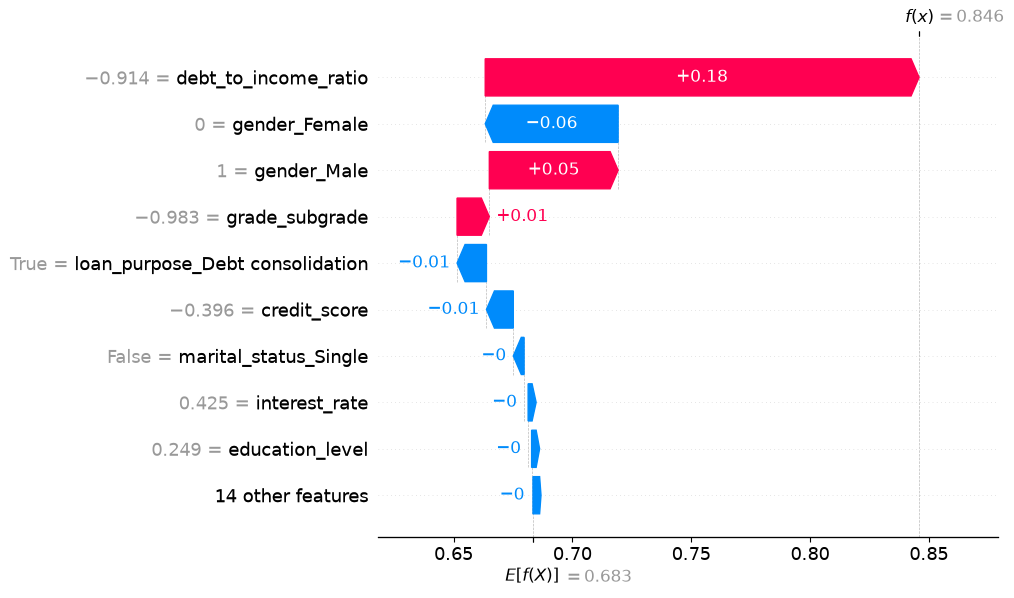

In [ ]:

blr_paid_prob = blr_paid_probability(
    X_analysis.iloc[[borrower_index]]
)[0]

print("Borrower index:", borrower_index)
print(
    "Actual label:",
    y_analysis.iloc[borrower_index]
)
print(
    f"BLR paid-back probability: {blr_paid_prob:.4f}"
)

blr_expected_value = float(
    np.asarray(
        blr_explainer.expected_value
    ).reshape(-1)[0]
)

blr_local_values = np.asarray(
    blr_shap_values[borrower_index]
).reshape(-1)

blr_local_data = X_analysis.iloc[
    borrower_index
].to_numpy().reshape(-1)

print(
    "BLR expected value:",
    blr_expected_value,
    type(blr_expected_value)
)

print(
    "BLR SHAP shape:",
    blr_local_values.shape
)

print(
    "BLR data shape:",
    blr_local_data.shape
)

print(
    "Number of feature names:",
    len(X_analysis.columns)
)

blr_local_explanation = shap.Explanation(
    values=blr_local_values,
    base_values=blr_expected_value,
    data=blr_local_data,
    feature_names=X_analysis.columns.tolist()
)

shap.plots.waterfall(
    blr_local_explanation,
    max_display=10
)

In [ ]:

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_background.values,
    feature_names=X_lime_background.columns.tolist(),
    class_names=["Default", "Paid Back"],
    mode="classification",

    discretize_continuous=False,

    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


,Feature,LIME_Weight,Absolute_LIME
0,employment_status_Unemployed,-0.264666,0.264666
1,debt_to_income_ratio,-0.119948,0.119948
2,credit_score,0.113648,0.113648
3,employment_status_Student,-0.082402,0.082402
4,employment_status_Retired,0.057206,0.057206
5,loan_purpose_Debt consolidation,-0.054125,0.054125
6,marital_status_Married,-0.052586,0.052586
7,marital_status_Single,-0.046818,0.046818
8,gender_Female,0.029425,0.029425
9,gender_Male,0.026829,0.026829


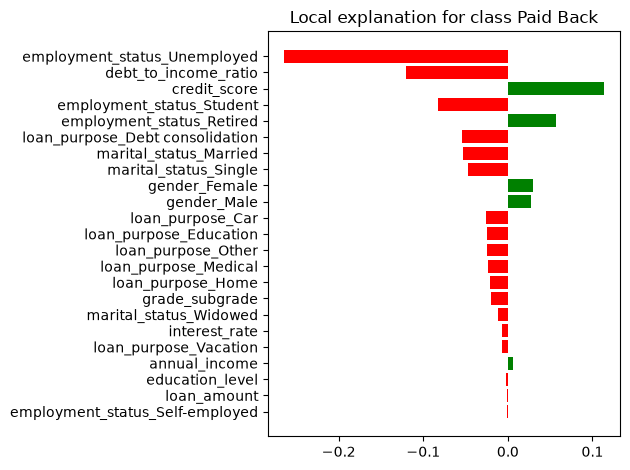

In [ ]:

lr_lime_exp = lime_explainer.explain_instance(
    data_row=X_analysis.iloc[borrower_index].values,
    predict_fn=lr_model.predict_proba,
    labels=(1,),
    num_features=X_analysis.shape[1],
    num_samples=5000
)

lr_lime_local_df = pd.DataFrame(
    lr_lime_exp.as_list(label=1),
    columns=["Feature", "LIME_Weight"]
)

lr_lime_local_df["Absolute_LIME"] = (
    lr_lime_local_df["LIME_Weight"].abs()
)

lr_lime_local_df = lr_lime_local_df.sort_values(
    "Absolute_LIME",
    ascending=False
).reset_index(drop=True)

display(lr_lime_local_df.head(10))

fig = lr_lime_exp.as_pyplot_figure(label=1)
plt.tight_layout()
plt.show()

,Feature,LIME_Weight,Absolute_LIME
0,debt_to_income_ratio,-0.036517,0.036517
1,employment_status_Unemployed,-0.034608,0.034608
2,education_level,-0.018339,0.018339
3,credit_score,0.013630,0.013630
4,employment_status_Student,-0.009905,0.009905
5,employment_status_Retired,0.008809,0.008809
6,loan_purpose_Debt consolidation,-0.008689,0.008689
7,annual_income,-0.006485,0.006485
8,marital_status_Single,-0.004796,0.004796
9,loan_purpose_Other,0.004590,0.004590


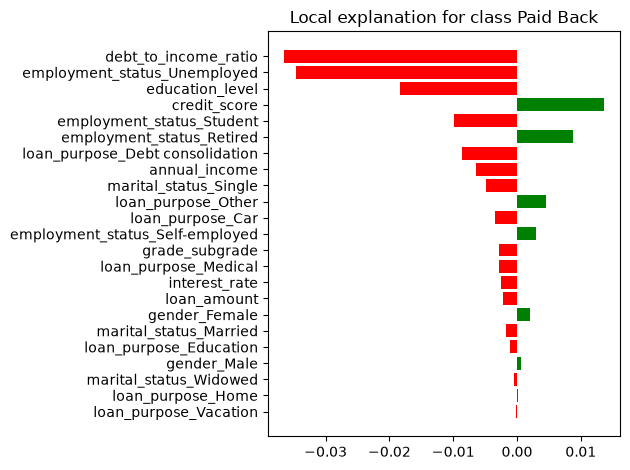

In [ ]:

gam_lime_exp = lime_explainer.explain_instance(
    data_row=X_analysis.iloc[borrower_index].values,
    predict_fn=gam_predict_proba,
    labels=(1,),
    num_features=X_analysis.shape[1],
    num_samples=5000
)

gam_lime_local_df = pd.DataFrame(
    gam_lime_exp.as_list(label=1),
    columns=["Feature", "LIME_Weight"]
)

gam_lime_local_df["Absolute_LIME"] = (
    gam_lime_local_df["LIME_Weight"].abs()
)

gam_lime_local_df = gam_lime_local_df.sort_values(
    "Absolute_LIME",
    ascending=False
).reset_index(drop=True)

display(gam_lime_local_df.head(10))

fig = gam_lime_exp.as_pyplot_figure(label=1)
plt.tight_layout()
plt.show()

,Feature,LIME_Weight,Absolute_LIME
0,debt_to_income_ratio,-0.000659,0.000659
1,marital_status_Single,-0.000646,0.000646
2,gender_Male,0.000632,0.000632
3,marital_status_Married,0.000623,0.000623
4,gender_Female,-0.000566,0.000566
5,loan_purpose_Debt consolidation,0.000500,0.000500
6,grade_subgrade,-0.000418,0.000418
7,employment_status_Unemployed,-0.000381,0.000381
8,education_level,0.000212,0.000212
9,loan_purpose_Other,-0.000196,0.000196


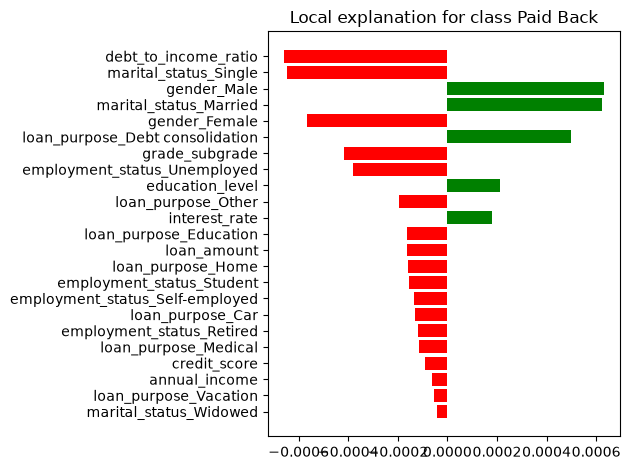

In [ ]:

ebm_lime_exp = lime_explainer.explain_instance(
    data_row=X_analysis.iloc[
        borrower_index
    ].values,
    predict_fn=ebm_predict_proba,
    labels=(1,),
    num_features=X_analysis.shape[1],
    num_samples=5000
)

ebm_lime_local_df = pd.DataFrame(
    ebm_lime_exp.as_list(label=1),
    columns=[
        "Feature",
        "LIME_Weight"
    ]
)

ebm_lime_local_df["Absolute_LIME"] = (
    ebm_lime_local_df[
        "LIME_Weight"
    ].abs()
)

ebm_lime_local_df = (
    ebm_lime_local_df
    .sort_values(
        "Absolute_LIME",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ebm_lime_local_df.head(10)
)

fig = ebm_lime_exp.as_pyplot_figure(
    label=1
)

plt.tight_layout()
plt.show()

,Feature,LIME_Weight,Absolute_LIME
0,employment_status_Unemployed,-0.270768,0.270768
1,debt_to_income_ratio,-0.128572,0.128572
2,credit_score,0.112546,0.112546
3,employment_status_Student,-0.086769,0.086769
4,employment_status_Retired,0.059681,0.059681
5,gender_Female,0.045279,0.045279
6,gender_Male,0.042621,0.042621
7,loan_purpose_Debt consolidation,-0.024528,0.024528
8,grade_subgrade,-0.013237,0.013237
9,loan_purpose_Education,-0.009880,0.009880


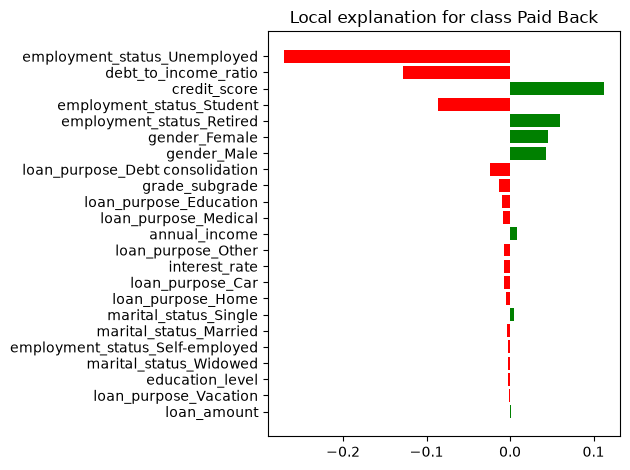

In [ ]:

blr_lime_exp = lime_explainer.explain_instance(
    data_row=X_analysis.iloc[
        borrower_index
    ].values,
    predict_fn=blr_predict_proba,
    labels=(1,),
    num_features=X_analysis.shape[1],
    num_samples=5000
)

blr_lime_local_df = pd.DataFrame(
    blr_lime_exp.as_list(label=1),
    columns=[
        "Feature",
        "LIME_Weight"
    ]
)

blr_lime_local_df["Absolute_LIME"] = (
    blr_lime_local_df[
        "LIME_Weight"
    ].abs()
)

blr_lime_local_df = (
    blr_lime_local_df
    .sort_values(
        "Absolute_LIME",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    blr_lime_local_df.head(10)
)

fig = blr_lime_exp.as_pyplot_figure(
    label=1
)

plt.tight_layout()
plt.show()

In [ ]:
def calculate_explanation_consistency(
    shap_values,
    lime_explanation,
    feature_names,
    top_k=5,
    lime_label=1
):
    """
    Compare local SHAP and LIME explanations using:

    1. Spearman rank correlation
    2. Top-k feature overlap
    3. Direction agreement among shared top-k features
    """

    feature_names = np.asarray(feature_names)
    shap_values = np.asarray(shap_values).flatten()

    if len(shap_values) != len(feature_names):
        raise ValueError(
            "The number of SHAP values does not match "
            "the number of feature names."
        )


    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_Value": shap_values
    })

    shap_df["Absolute_SHAP"] = (
        shap_df["SHAP_Value"].abs()
    )

    shap_df = shap_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    shap_df["SHAP_Rank"] = np.arange(
        1,
        len(shap_df) + 1
    )

    lime_map = lime_explanation.as_map()[lime_label]

    lime_scaled_row = np.asarray(
        lime_explanation.domain_mapper.scaled_row
    ).reshape(-1)

    lime_df = pd.DataFrame({
        "Feature_Index": [
            feature_index
            for feature_index, weight in lime_map
        ],
        "LIME_Weight": [
            weight
            for feature_index, weight in lime_map
        ]
    })

    lime_df["Feature"] = lime_df[
        "Feature_Index"
    ].map(
        lambda index: feature_names[index]
    )

    lime_df["LIME_Feature_Value"] = lime_df[
        "Feature_Index"
    ].map(
        lambda index: lime_scaled_row[index]
    )
    
    lime_df["LIME_Contribution"] = (
        lime_df["LIME_Weight"]
        * lime_df["LIME_Feature_Value"]
    )

    lime_df["Absolute_LIME"] = lime_df[
        "LIME_Contribution"
    ].abs()

    lime_df = lime_df.sort_values(
        "Absolute_LIME",
        ascending=False
    ).reset_index(drop=True)

    lime_df["LIME_Rank"] = np.arange(
        1,
        len(lime_df) + 1
    )


    comparison = pd.merge(
        shap_df,
        lime_df[
            [
                "Feature",
                "LIME_Weight",
                "LIME_Feature_Value",
                "LIME_Contribution",
                "Absolute_LIME",
                "LIME_Rank"
            ]
        ],
        on="Feature",
        how="inner"
    )

    comparison["SHAP_Direction"] = np.sign(
        comparison["SHAP_Value"]
    )

    comparison["LIME_Direction"] = np.sign(
        comparison["LIME_Contribution"]
    )

    if len(comparison) < 2:
        metrics = {
            "Spearman_Correlation": np.nan,
            "Spearman_P_Value": np.nan,
            "Top_K_Overlap": np.nan,
            "Top_K_Direction_Agreement": np.nan,
            "Shared_Top_K_Count": 0
        }

        return metrics, comparison

    spearman_correlation, p_value = spearmanr(
        comparison["SHAP_Rank"],
        comparison["LIME_Rank"]
    )

    effective_k = min(
        top_k,
        len(shap_df),
        len(lime_df)
    )

    shap_top_features = set(
        shap_df.head(effective_k)["Feature"]
    )

    lime_top_features = set(
        lime_df.head(effective_k)["Feature"]
    )

    shared_top_features = (
        shap_top_features.intersection(
            lime_top_features
        )
    )

    top_k_overlap = (
        len(shared_top_features) / effective_k
    )

    shared_comparison = comparison[
        comparison["Feature"].isin(
            shared_top_features
        )
    ].copy()

    if len(shared_comparison) == 0:
        direction_agreement = np.nan
    else:
        direction_agreement = (
            shared_comparison["SHAP_Direction"]
            == shared_comparison["LIME_Direction"]
        ).mean()

    metrics = {
        "Spearman_Correlation": spearman_correlation,
        "Spearman_P_Value": p_value,
        "Top_K_Overlap": top_k_overlap,
        "Top_K_Direction_Agreement": direction_agreement,
        "Shared_Top_K_Count": len(shared_top_features)
    }

    return metrics, comparison

In [ ]:

lr_metrics, lr_comparison_table = (
    calculate_explanation_consistency(
        shap_values=lr_shap_values.values[
            borrower_index
        ],
        lime_explanation=lr_lime_exp,
        feature_names=X_analysis.columns,
        top_k=5
    )
)

gam_metrics, gam_comparison_table = (
    calculate_explanation_consistency(
        shap_values=gam_shap_values[
            borrower_index
        ],
        lime_explanation=gam_lime_exp,
        feature_names=X_analysis.columns,
        top_k=5
    )
)

ebm_metrics, ebm_comparison_table = (
    calculate_explanation_consistency(
        shap_values=ebm_shap_values[
            borrower_index
        ],
        lime_explanation=ebm_lime_exp,
        feature_names=X_analysis.columns,
        top_k=5
    )
)

blr_metrics, blr_comparison_table = (
    calculate_explanation_consistency(
        shap_values=blr_shap_values[
            borrower_index
        ],
        lime_explanation=blr_lime_exp,
        feature_names=X_analysis.columns,
        top_k=5
    )
)

one_borrower_results = pd.DataFrame([
    {
        "Borrower": borrower_index,
        "Model": "LR",
        **lr_metrics
    },
    {
        "Borrower": borrower_index,
        "Model": "GAM",
        **gam_metrics
    },
    {
        "Borrower": borrower_index,
        "Model": "EBM",
        **ebm_metrics
    },
    {
        "Borrower": borrower_index,
        "Model": "BLR",
        **blr_metrics
    }
])

display(
    one_borrower_results.style.format({
        "Spearman_Correlation": "{:.6f}",
        "Spearman_P_Value": "{:.15f}",
        "Top_K_Overlap": "{:.1f}",
        "Top_K_Direction_Agreement": "{:.6f}"
    })
)

,Borrower,Model,Spearman_Correlation,Spearman_P_Value,Top_K_Overlap,Top_K_Direction_Agreement,Shared_Top_K_Count
0,0,LR,0.965415,0.000000000000098,1.0,1.000000,5
1,0,GAM,0.555336,0.005944140761734,0.6,0.666667,3
2,0,EBM,0.308300,0.152360926687910,0.4,0.500000,2
3,0,BLR,0.490119,0.017589302048694,0.6,1.000000,3


In [ ]:

print("LR SHAP-LIME comparison")
display(
    lr_comparison_table
    .sort_values("SHAP_Rank")
    .head(10)
)

print("\nGAM SHAP-LIME comparison")
display(
    gam_comparison_table
    .sort_values("SHAP_Rank")
    .head(10)
)

print("\nEBM SHAP-LIME comparison")
display(
    ebm_comparison_table
    .sort_values("SHAP_Rank")
    .head(10)
)

print("\nBLR SHAP-LIME comparison")
display(
    blr_comparison_table
    .sort_values("SHAP_Rank")
    .head(10)
)

LR SHAP-LIME comparison


,Feature,SHAP_Value,Absolute_SHAP,SHAP_Rank,LIME_Weight,LIME_Feature_Value,LIME_Contribution,Absolute_LIME,LIME_Rank,SHAP_Direction,LIME_Direction
0,employment_status_Unemployed,1.614538,1.614538,1,-0.264666,-0.605079,0.160144,0.160144,1,1,1.0
1,debt_to_income_ratio,1.003114,1.003114,2,-0.119948,-1.004873,0.120533,0.120533,2,1,1.0
2,marital_status_Married,-0.52747,0.52747,3,-0.052586,1.072631,-0.056405,0.056405,3,-1,-1.0
3,marital_status_Single,0.440951,0.440951,4,-0.046818,-0.987413,0.046229,0.046229,4,1,1.0
4,loan_purpose_Debt consolidation,-0.347837,0.347837,5,-0.054125,0.835915,-0.045244,0.045244,5,-1,-1.0
5,credit_score,-0.253326,0.253326,6,0.113648,-0.233111,-0.026493,0.026493,8,-1,-1.0
6,gender_Female,-0.235436,0.235436,7,0.029425,-1.003339,-0.029523,0.029523,6,-1,-1.0
7,gender_Male,0.214449,0.214449,8,0.026829,1.015453,0.027244,0.027244,7,1,1.0
8,employment_status_Student,0.168656,0.168656,9,-0.082402,-0.211972,0.017467,0.017467,9,1,1.0
9,grade_subgrade,0.145627,0.145627,10,-0.020138,-0.832235,0.016759,0.016759,10,1,1.0



GAM SHAP-LIME comparison


,Feature,SHAP_Value,Absolute_SHAP,SHAP_Rank,LIME_Weight,LIME_Feature_Value,LIME_Contribution,Absolute_LIME,LIME_Rank,SHAP_Direction,LIME_Direction
0,education_level,0.582630,0.582630,1,-0.018339,0.276615,-0.005073,0.005073,4,1.0,-1.0
1,debt_to_income_ratio,0.166506,0.166506,2,-0.036517,-1.004873,0.036695,0.036695,1,1.0,1.0
2,marital_status_Married,-0.045588,0.045588,3,-0.001784,1.072631,-0.001913,0.001913,10,-1.0,-1.0
3,marital_status_Single,0.043681,0.043681,4,-0.004796,-0.987413,0.004735,0.004735,5,1.0,1.0
4,gender_Female,-0.025532,0.025532,5,0.002082,-1.003339,-0.002089,0.002089,9,-1.0,-1.0
5,gender_Male,0.023861,0.023861,6,0.000571,1.015453,0.000579,0.000579,16,1.0,1.0
6,grade_subgrade,0.018133,0.018133,7,-0.002861,-0.832235,0.002381,0.002381,7,1.0,1.0
7,loan_purpose_Debt consolidation,-0.016881,0.016881,8,-0.008689,0.835915,-0.007263,0.007263,3,-1.0,-1.0
8,loan_amount,-0.011855,0.011855,9,-0.002180,-0.218850,0.000477,0.000477,19,-1.0,1.0
9,credit_score,-0.005599,0.005599,10,0.013630,-0.233111,-0.003177,0.003177,6,-1.0,-1.0



EBM SHAP-LIME comparison


,Feature,SHAP_Value,Absolute_SHAP,SHAP_Rank,LIME_Weight,LIME_Feature_Value,LIME_Contribution,Absolute_LIME,LIME_Rank,SHAP_Direction,LIME_Direction
0,grade_subgrade,0.259863,0.259863,1,-0.000418,-0.832235,0.000348,0.000348,7,1.0,1.0
1,education_level,0.256974,0.256974,2,0.000212,0.276615,0.000059,0.000059,11,1.0,1.0
2,debt_to_income_ratio,0.202366,0.202366,3,-0.000659,-1.004873,0.000662,0.000662,2,1.0,1.0
3,credit_score,0.182206,0.182206,4,-0.000089,-0.233111,0.000021,0.000021,19,1.0,1.0
4,gender_Female,-0.087068,0.087068,5,-0.000566,-1.003339,0.000568,0.000568,5,-1.0,1.0
5,loan_amount,0.080821,0.080821,6,-0.000162,-0.218850,0.000035,0.000035,16,1.0,1.0
6,interest_rate,0.043984,0.043984,7,0.000179,0.349035,0.000063,0.000063,10,1.0,1.0
7,loan_purpose_Debt consolidation,-0.027282,0.027282,8,0.000500,0.835915,0.000418,0.000418,6,-1.0,1.0
8,marital_status_Single,0.021803,0.021803,9,-0.000646,-0.987413,0.000637,0.000637,4,1.0,1.0
9,gender_Male,0.011765,0.011765,10,0.000632,1.015453,0.000641,0.000641,3,1.0,1.0



BLR SHAP-LIME comparison


,Feature,SHAP_Value,Absolute_SHAP,SHAP_Rank,LIME_Weight,LIME_Feature_Value,LIME_Contribution,Absolute_LIME,LIME_Rank,SHAP_Direction,LIME_Direction
0,debt_to_income_ratio,0.182554,0.182554,1,-0.128572,-1.004873,0.129199,0.129199,2,1.0,1.0
1,gender_Female,-0.055923,0.055923,2,0.045279,-1.003339,-0.045430,0.045430,3,-1.0,-1.0
2,gender_Male,0.054198,0.054198,3,0.042621,1.015453,0.043280,0.043280,4,1.0,1.0
3,grade_subgrade,0.013570,0.013570,4,-0.013237,-0.832235,0.011016,0.011016,8,1.0,1.0
4,loan_purpose_Debt consolidation,-0.012361,0.012361,5,-0.024528,0.835915,-0.020503,0.020503,6,-1.0,-1.0
5,credit_score,-0.011299,0.011299,6,0.112546,-0.233111,-0.026236,0.026236,5,-1.0,-1.0
6,marital_status_Single,-0.004539,0.004539,7,0.004464,-0.987413,-0.004408,0.004408,10,-1.0,-1.0
7,interest_rate,-0.001704,0.001704,8,-0.006815,0.349035,-0.002379,0.002379,14,-1.0,-1.0
8,education_level,-0.001465,0.001465,9,-0.001892,0.276615,-0.000523,0.000523,20,-1.0,-1.0
9,annual_income,-0.000581,0.000581,10,0.007973,-0.073812,-0.000589,0.000589,19,-1.0,-1.0


In [ ]:

consistency_results = []

for i in range(len(X_analysis)):

    print(
        f"Processing borrower "
        f"{i + 1}/{len(X_analysis)}",
        end="\r"
    )

    borrower_row = X_analysis.iloc[i].values

    lr_lime_i = lime_explainer.explain_instance(
        data_row=borrower_row,
        predict_fn=lr_model.predict_proba,
        labels=(1,),
        num_features=X_analysis.shape[1],
        num_samples=5000
    )

    lr_metrics_i, _ = (
        calculate_explanation_consistency(
            shap_values=lr_shap_values.values[i],
            lime_explanation=lr_lime_i,
            feature_names=X_analysis.columns,
            top_k=5
        )
    )

    consistency_results.append({
        "Borrower": i,
        "Actual_Label": y_analysis.iloc[i],
        "Model": "LR",
        **lr_metrics_i
    })

    gam_lime_i = lime_explainer.explain_instance(
        data_row=borrower_row,
        predict_fn=gam_predict_proba,
        labels=(1,),
        num_features=X_analysis.shape[1],
        num_samples=5000
    )

    gam_metrics_i, _ = (
        calculate_explanation_consistency(
            shap_values=gam_shap_values[i],
            lime_explanation=gam_lime_i,
            feature_names=X_analysis.columns,
            top_k=5
        )
    )

    consistency_results.append({
        "Borrower": i,
        "Actual_Label": y_analysis.iloc[i],
        "Model": "GAM",
        **gam_metrics_i
    })

    ebm_lime_i = lime_explainer.explain_instance(
        data_row=borrower_row,
        predict_fn=ebm_predict_proba,
        labels=(1,),
        num_features=X_analysis.shape[1],
        num_samples=5000
    )

    ebm_metrics_i, _ = (
        calculate_explanation_consistency(
            shap_values=ebm_shap_values[i],
            lime_explanation=ebm_lime_i,
            feature_names=X_analysis.columns,
            top_k=5
        )
    )

    consistency_results.append({
        "Borrower": i,
        "Actual_Label": y_analysis.iloc[i],
        "Model": "EBM",
        **ebm_metrics_i
    })

    blr_lime_i = lime_explainer.explain_instance(
        data_row=borrower_row,
        predict_fn=blr_predict_proba,
        labels=(1,),
        num_features=X_analysis.shape[1],
        num_samples=5000
    )

    blr_metrics_i, _ = (
        calculate_explanation_consistency(
            shap_values=blr_shap_values[i],
            lime_explanation=blr_lime_i,
            feature_names=X_analysis.columns,
            top_k=5
        )
    )

    consistency_results.append({
        "Borrower": i,
        "Actual_Label": y_analysis.iloc[i],
        "Model": "BLR",
        **blr_metrics_i
    })

print("\nCompleted.")

consistency_results_df = pd.DataFrame(
    consistency_results
)

display(
    consistency_results_df.head(12)
)

Processing borrower 100/100
Completed.


,Borrower,Actual_Label,Model,Spearman_Correlation,Spearman_P_Value,Top_K_Overlap,Top_K_Direction_Agreement,Shared_Top_K_Count
0,0,1.0,LR,0.966403,7.225576e-14,1.0,1.000000,5
1,0,1.0,GAM,0.485178,1.894252e-02,0.6,0.666667,3
2,0,1.0,EBM,0.198617,3.636086e-01,0.4,0.500000,2
3,0,1.0,BLR,0.447628,3.220786e-02,0.6,1.000000,3
4,1,1.0,LR,0.978261,7.877399e-16,1.0,1.000000,5
5,1,1.0,GAM,0.577075,3.939387e-03,0.4,1.000000,2
6,1,1.0,EBM,0.264822,2.220235e-01,0.4,1.000000,2
7,1,1.0,BLR,0.571146,4.419274e-03,0.8,1.000000,4
8,2,1.0,LR,0.959486,5.004227e-13,1.0,1.000000,5
9,2,1.0,GAM,0.620553,1.581311e-03,0.4,1.000000,2


In [27]:
consistency_summary = (
    consistency_results_df
    .groupby("Model")[
        [
            "Spearman_Correlation",
            "Top_K_Overlap",
            "Top_K_Direction_Agreement"
        ]
    ]
    .agg(["mean", "std"])
)

display(consistency_summary)


Spearman_Correlation           Top_K_Overlap            \
                      mean       std          mean       std   
Model                                                          
BLR               0.595059  0.084930         0.822  0.109710   
EBM               0.481334  0.155418         0.398  0.189620   
GAM               0.606265  0.113555         0.610  0.145990   
LR                0.955287  0.023003         0.956  0.083267   

      Top_K_Direction_Agreement            
                           mean       std  
Model                                      
BLR                    1.000000  0.000000  
EBM                    0.803763  0.297596  
GAM                    0.880000  0.173803  
LR                     1.000000  0.000000

In [28]:
consistency_results_df.groupby("Model")[
    "Shared_Top_K_Count"
].describe()

,count,mean,std,min,25%,50%,75%,max
Model,,,,,,,,
BLR,100.0,4.11,0.548552,3.0,4.0,4.0,4.0,5.0
EBM,100.0,1.99,0.948098,0.0,1.0,2.0,3.0,4.0
GAM,100.0,3.05,0.729951,1.0,3.0,3.0,3.0,5.0
LR,100.0,4.78,0.416333,4.0,5.0,5.0,5.0,5.0


In [ ]:

import pandas as pd
import numpy as np

lr_final_df = lr_performance_df[
    ["Metric", "Tuned LR"]
].rename(
    columns={"Tuned LR": "LR"}
)

gam_final_df = gam_performance_df[
    ["Metric", "GAM"]
].copy()

performance_comparison_df = pd.merge(
    lr_final_df,
    gam_final_df,
    on="Metric",
    how="inner"
)

performance_comparison_df[
    "Difference (GAM - LR)"
] = (
    performance_comparison_df["GAM"]
    - performance_comparison_df["LR"]
)

higher_is_better = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

performance_comparison_df[
    "Improvement in Favour of GAM"
] = np.where(
    performance_comparison_df["Metric"].isin(
        higher_is_better
    ),
    performance_comparison_df["GAM"]
    - performance_comparison_df["LR"],
    performance_comparison_df["LR"]
    - performance_comparison_df["GAM"]
)

performance_comparison_df[
    "Better Model"
] = np.where(
    performance_comparison_df[
        "Improvement in Favour of GAM"
    ] > 0,
    "GAM",
    np.where(
        performance_comparison_df[
            "Improvement in Favour of GAM"
        ] < 0,
        "LR",
        "Equal"
    )
)

display(
    performance_comparison_df.round(6)
)

,Metric,LR,GAM,Difference (GAM - LR),Improvement in Favour of GAM,Better Model
0,Accuracy,0.863324,0.867432,0.004108,0.004108,GAM
1,Precision,0.936060,0.936357,0.000296,0.000296,GAM
2,Recall,0.889485,0.894686,0.005200,0.005200,GAM
3,F1 Score,0.912179,0.915047,0.002868,0.002868,GAM
4,ROC-AUC,0.908984,0.909665,0.000681,0.000681,GAM
5,Log Loss,0.344576,0.331237,-0.013338,0.013338,GAM
6,Brier Score,0.104507,0.101636,-0.002871,0.002871,GAM
7,Training Time,24.084944,1769.837162,1745.752218,-1745.752218,LR


In [44]:
print(consistency_results_df.columns.tolist())

display(consistency_results_df.head())

['Borrower', 'Actual_Label', 'Model', 'Spearman_Correlation', 'Spearman_P_Value', 'Top_K_Overlap', 'Top_K_Direction_Agreement', 'Shared_Top_K_Count']


,Borrower,Actual_Label,Model,Spearman_Correlation,Spearman_P_Value,Top_K_Overlap,Top_K_Direction_Agreement,Shared_Top_K_Count
0,0,1.0,LR,0.966403,7.225576e-14,1.0,1.000000,5
1,0,1.0,GAM,0.485178,1.894252e-02,0.6,0.666667,3
2,0,1.0,EBM,0.198617,3.636086e-01,0.4,0.500000,2
3,0,1.0,BLR,0.447628,3.220786e-02,0.6,1.000000,3
4,1,1.0,LR,0.978261,7.877399e-16,1.0,1.000000,5


In [46]:


rq3_consistency = consistency_results_df[
    consistency_results_df["Model"].isin(["LR", "GAM"])
].copy()

metrics = [
    "Spearman_Correlation",
    "Top_K_Overlap",
    "Top_K_Direction_Agreement"
]

rq3_results = []

for metric in metrics:

    paired = (
        rq3_consistency
        .pivot(
            index="Borrower",
            columns="Model",
            values=metric
        )
        .dropna()
    )

    lr = paired["LR"]
    gam = paired["GAM"]

    statistic, p = wilcoxon(
        lr,
        gam,
        alternative="two-sided"
    )

    rq3_results.append({
        "Metric": metric,
        "LR Mean": lr.mean(),
        "GAM Mean": gam.mean(),
        "Mean Difference (GAM-LR)": gam.mean() - lr.mean(),
        "P Value": p,
        "Significant": p < 0.05
    })

rq3_results_df = pd.DataFrame(rq3_results)

display(rq3_results_df.round(4))

,Metric,LR Mean,GAM Mean,Mean Difference (GAM-LR),P Value,Significant
0,Spearman_Correlation,0.9553,0.6063,-0.349,0.0,True
1,Top_K_Overlap,0.9560,0.6100,-0.346,0.0,True
2,Top_K_Direction_Agreement,1.0000,0.8800,-0.120,0.0,True


In [ ]:

rq3_summary_df = pd.DataFrame({

    "Dimension":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Log Loss",
        "Brier Score",
        "Spearman Consistency",
        "Top-K Overlap",
        "Direction Agreement",
        "Structural Transparency",
        "Functional Complexity"
    ],

    "Better Model":[
        "GAM",
        "GAM",
        "GAM",
        "GAM",
        "GAM",
        "GAM",
        "GAM",
        "LR",
        "LR",
        "LR",
        "LR",
        "LR"
    ],

    "Evidence":[
        "Higher",
        "Higher",
        "Higher",
        "Higher",
        "Higher",
        "Lower",
        "Lower",
        "Higher SHAP-LIME correlation",
        "Higher feature overlap",
        "Higher direction agreement",
        "Linear coefficients",
        "Simpler model"
    ]

})

display(rq3_summary_df)

,Dimension,Better Model,Evidence
0,Accuracy,GAM,Higher
1,Precision,GAM,Higher
2,Recall,GAM,Higher
3,F1 Score,GAM,Higher
4,ROC-AUC,GAM,Higher
5,Log Loss,GAM,Lower
6,Brier Score,GAM,Lower
7,Spearman Consistency,LR,Higher SHAP-LIME correlation
8,Top-K Overlap,LR,Higher feature overlap
9,Direction Agreement,LR,Higher direction agreement
